# Assignment 6: Model Evaluation, Explainability, and Fairness Reflection
**Course:** MBAI 5310G – AI Programming  
**Dataset:** Event Registration & Attendance Dataset  
**Model:** Decision Tree Classifier  
**Target Variable:** `attended_event` (1 = Attended, 0 = Did Not Attend)


## Task 1: Load and Understand the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/event_registration_attendance_dataset.csv')

print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


=== Dataset Shape ===
Rows: 380, Columns: 17


In [2]:
print("=== Column Names and Data Types ===")
print(df.dtypes)


=== Column Names and Data Types ===
registration_id                  object
age                               int64
age_group                        object
gender                           object
region                           object
ticket_type                      object
registration_channel             object
event_category                   object
days_before_event_registered      int64
ticket_price                    float64
previous_events_attended          int64
email_reminders_opened            int64
social_media_clicks               int64
distance_to_venue_km            float64
group_registration               object
calendar_invite_accepted         object
attended_event                    int64
dtype: object


In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
registration_id                 0
age                             0
age_group                       0
gender                          0
region                          0
ticket_type                     0
registration_channel            0
event_category                  0
days_before_event_registered    0
ticket_price                    7
previous_events_attended        0
email_reminders_opened          0
social_media_clicks             0
distance_to_venue_km            5
group_registration              0
calendar_invite_accepted        0
attended_event                  0
dtype: int64


In [4]:
print(f"=== Duplicate Records ===")
print(f"Duplicates: {df.duplicated().sum()}")


=== Duplicate Records ===
Duplicates: 0


In [5]:
print("=== Target Variable Distribution ===")
dist = df['attended_event'].value_counts()
print(dist)
print(f"\nAttended:     {dist[1]} ({dist[1]/len(df)*100:.1f}%)")
print(f"Not Attended: {dist[0]} ({dist[0]/len(df)*100:.1f}%)")


=== Target Variable Distribution ===
attended_event
1    233
0    147
Name: count, dtype: int64

Attended:     233 (61.3%)
Not Attended: 147 (38.7%)


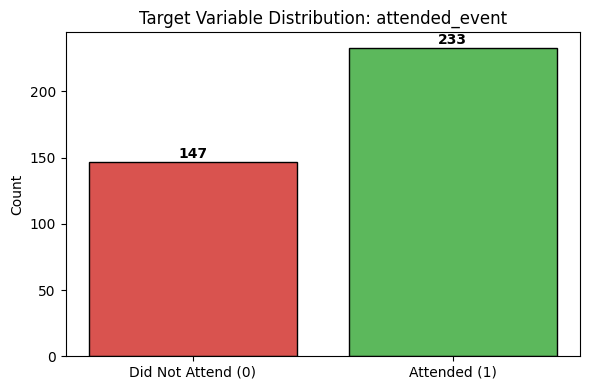

In [6]:
# Visualize target distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Did Not Attend (0)', 'Attended (1)'], 
       [dist[0], dist[1]], 
       color=['#d9534f', '#5cb85c'], edgecolor='black')
ax.set_title('Target Variable Distribution: attended_event')
ax.set_ylabel('Count')
for i, v in enumerate([dist[0], dist[1]]):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
df.head()


,registration_id,age,age_group,gender,region,ticket_type,registration_channel,event_category,days_before_event_registered,ticket_price,previous_events_attended,email_reminders_opened,social_media_clicks,distance_to_venue_km,group_registration,calendar_invite_accepted,attended_event
0,EV0001,36,36-50,Male,North,VIP,Phone,Business,70,197.0,14,6,11,11.2,Yes,Yes,1
1,EV0002,57,51+,Female,South,Free,Mobile App,Arts,22,0.0,1,1,12,54.6,Yes,Yes,1
2,EV0003,64,51+,Female,East,Free,Partner Site,Technology,55,0.0,6,5,2,75.8,No,No,0
3,EV0004,42,36-50,Male,West,VIP,Mobile App,Education,60,413.0,18,5,0,90.2,No,Yes,1
4,EV0005,29,26-35,Male,East,Student,Phone,Business,44,26.0,11,0,6,25.3,No,No,1


**Dataset Description:**  
This dataset contains event registration records for 380 attendees. Each row represents one registered person. The target variable, `attended_event`, is a binary flag (1 = attended, 0 = did not attend) that the model will try to predict.

The dataset has **numerical features** such as age, ticket price, email reminders opened, and distance to the venue, alongside **categorical features** such as ticket type, registration channel, event category, and region.

**Target Variable Balance:**  
The target variable is slightly imbalanced — 233 attendees (61.3%) attended the event while 147 (38.7%) did not. This mild imbalance means accuracy alone may be misleading and recall/F1 should be monitored carefully.

**Missing Values:**  
Two columns have a small number of missing values: `ticket_price` (7 missing) and `distance_to_venue_km` (5 missing). These will be handled during preprocessing.  
No duplicate records were found.


## Task 2: Define Features and Target Variable

In [8]:
# Target variable
TARGET = 'attended_event'

# Identifier to drop
ID_COL = 'registration_id'

# Group/fairness columns — kept separate, NOT used as model input
FAIRNESS_COLS = ['gender', 'age_group', 'region']

# Derived/redundant columns to exclude (age_group is a derived form of age)
# age_group is also a fairness column, so it's excluded for both reasons

# All remaining columns are model features
MODEL_FEATURES = [c for c in df.columns 
                  if c not in [TARGET, ID_COL] + FAIRNESS_COLS]

print("Target variable:", TARGET)
print("\nModel input features:")
for f in MODEL_FEATURES:
    print(" ", f)
print("\nColumns dropped (identifier):", ID_COL)
print("\nColumns kept for fairness only (NOT model input):", FAIRNESS_COLS)


Target variable: attended_event

Model input features:
  age
  ticket_type
  registration_channel
  event_category
  days_before_event_registered
  ticket_price
  previous_events_attended
  email_reminders_opened
  social_media_clicks
  distance_to_venue_km
  group_registration
  calendar_invite_accepted

Columns dropped (identifier): registration_id

Columns kept for fairness only (NOT model input): ['gender', 'age_group', 'region']


In [9]:
# Separate feature types
NUM_FEATURES = df[MODEL_FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df[MODEL_FEATURES].select_dtypes(include='object').columns.tolist()

print("Numerical features:", NUM_FEATURES)
print("Categorical features:", CAT_FEATURES)


Numerical features: ['age', 'days_before_event_registered', 'ticket_price', 'previous_events_attended', 'email_reminders_opened', 'social_media_clicks', 'distance_to_venue_km']
Categorical features: ['ticket_type', 'registration_channel', 'event_category', 'group_registration', 'calendar_invite_accepted']


**Feature Design Decisions:**

- **Target variable:** `attended_event` — a binary label (1 = attended, 0 = did not attend).
- **Identifier removed:** `registration_id` is a unique record ID with no predictive value; it was dropped.
- **Fairness columns (not model input):** `gender`, `age_group`, and `region` are group-related columns retained separately for fairness analysis. They are excluded as model features to prevent the model from making predictions based on protected characteristics, and to allow an unbiased assessment of how model performance varies across these groups.
- **Model input features:** All remaining columns — a mix of numerical features (age, ticket price, prior attendance history, engagement metrics, distance) and categorical features (ticket type, registration channel, event category, group registration, calendar invite accepted).


## Task 3: Data Preprocessing

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Numerical pipeline: impute median → no scaling needed for Decision Tree
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: impute mode → one-hot encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combined preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_FEATURES),
    ('cat', cat_pipeline, CAT_FEATURES)
])

print("Preprocessing pipeline created:")
print(" - Numerical:", NUM_FEATURES)
print(" - Categorical:", CAT_FEATURES)


Preprocessing pipeline created:
 - Numerical: ['age', 'days_before_event_registered', 'ticket_price', 'previous_events_attended', 'email_reminders_opened', 'social_media_clicks', 'distance_to_venue_km']
 - Categorical: ['ticket_type', 'registration_channel', 'event_category', 'group_registration', 'calendar_invite_accepted']


**Why Preprocessing Is Necessary:**  
Raw data cannot be fed directly into most machine learning algorithms. The `ticket_price` and `distance_to_venue_km` columns contain missing values that must be handled — otherwise the model will raise errors during training. Categorical columns such as `ticket_type` and `registration_channel` must be converted to numerical format (via one-hot encoding) because Decision Trees require numerical inputs.

Critically, the preprocessing pipeline is **fitted only on the training data** and applied to the test data, preventing **data leakage** — a situation where test-set information inadvertently influences the training process and inflates performance estimates. Using scikit-learn's `Pipeline` + `ColumnTransformer` enforces this discipline automatically.


## Task 4: Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df[MODEL_FEATURES].copy()
y = df[TARGET].copy()
fairness_df = df[FAIRNESS_COLS].copy()

X_train, X_test, y_train, y_test, fair_train, fair_test = train_test_split(
    X, y, fairness_df, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} records ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:   {X_test.shape[0]} records  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTarget distribution in training set:\n{y_train.value_counts()}")
print(f"\nTarget distribution in testing set:\n{y_test.value_counts()}")


Training set:  304 records (80.0%)
Testing set:   76 records  (20.0%)

Target distribution in training set:
attended_event
1    186
0    118
Name: count, dtype: int64

Target distribution in testing set:
attended_event
1    47
0    29
Name: count, dtype: int64


**Training vs. Testing Data:**

The dataset is split 80/20 into training and testing sets. The **training set** (304 records) is used to teach the model — the algorithm learns patterns between features and the target label from this data. The **testing set** (76 records) is held out entirely during training and used only to evaluate how well the model generalises to new, unseen data.

Stratified splitting (`stratify=y`) is used to preserve the same class ratio in both sets, ensuring the mild imbalance (61% attended) is reflected equally in training and testing. A fixed `random_state=42` ensures reproducibility.


## Task 5: Train a Classification Model

In [12]:
from sklearn.tree import DecisionTreeClassifier

# Unconstrained tree (for comparison only — not the final model)
clf_unconstrained = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
clf_unconstrained.fit(X_train, y_train)

# Final (controlled) model — max_depth=4 to prevent overfitting
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])
clf.fit(X_train, y_train)

print("Unconstrained tree trained (depth:", clf_unconstrained.named_steps['classifier'].get_depth(), ")")
print("Controlled tree trained   (depth:", clf.named_steps['classifier'].get_depth(), ")")


Unconstrained tree trained (depth: 8 )
Controlled tree trained   (depth: 4 )


In [13]:
# Predictions
y_pred = clf.predict(X_test)

# Comparison table — first 15 rows
comparison = pd.DataFrame({
    'Actual': y_test.values[:15],
    'Predicted': y_pred[:15],
    'Correct': (y_test.values[:15] == y_pred[:15])
})
comparison.index = range(1, 16)
print("=== Actual vs. Predicted (first 15 records) ===")
print(comparison.to_string())


=== Actual vs. Predicted (first 15 records) ===
    Actual  Predicted  Correct
1        1          1     True
2        0          0     True
3        1          1     True
4        0          1    False
5        0          1    False
6        0          0     True
7        1          0    False
8        1          1     True
9        0          1    False
10       1          1     True
11       0          0     True
12       0          1    False
13       0          1    False
14       1          1     True
15       1          1     True


**What the Model Is Learning:**  
The Decision Tree learns a series of yes/no decision rules about the features — for example, "did this registrant open more than 3 email reminders?" or "was the ticket price above $100?" — and chains them together to classify whether a person will attend the event.

Examining the first 15 predictions shows a mix of correct and incorrect predictions, which is expected. The model is not memorising training records; it is applying learned rules to new, unseen registrants. The final **controlled model** (max_depth=4) is used for all evaluations to balance accuracy with generalisability.


## Task 6: Evaluate the Model

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Model Evaluation Metrics (Controlled Tree, max_depth=4) ===")
print(f"Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Did Not Attend', 'Attended']))


=== Model Evaluation Metrics (Controlled Tree, max_depth=4) ===
Accuracy:  0.8158  (81.58%)
Precision: 0.8235
Recall:    0.8936
F1-Score:  0.8571

                precision    recall  f1-score   support

Did Not Attend       0.80      0.69      0.74        29
      Attended       0.82      0.89      0.86        47

      accuracy                           0.82        76
     macro avg       0.81      0.79      0.80        76
  weighted avg       0.81      0.82      0.81        76



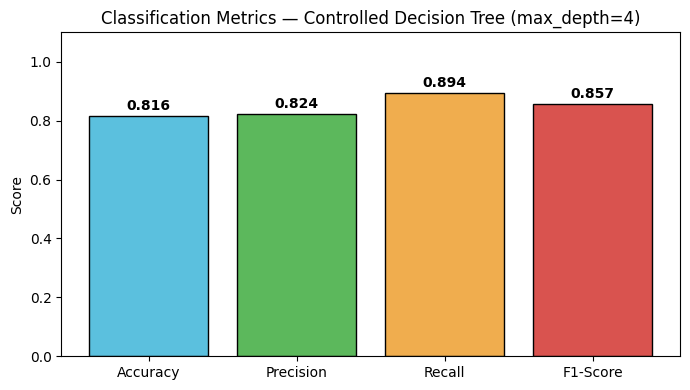

In [15]:
# Metric visualisation
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics.keys(), metrics.values(), color=['#5bc0de','#5cb85c','#f0ad4e','#d9534f'], edgecolor='black')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Metrics — Controlled Decision Tree (max_depth=4)')
ax.set_ylabel('Score')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Metric Explanations:**

- **Accuracy:** The percentage of all predictions (both attended and not attended) that were correct. Useful as a quick overview, but can be misleading with imbalanced classes.
- **Precision:** Of all registrants the model *predicted* would attend, what fraction actually did? High precision means fewer wasted follow-up resources sent to people who won't show.
- **Recall:** Of all registrants who *actually* attended, what fraction did the model correctly identify? High recall means fewer missed attendees — important if the goal is to identify all likely attendees for seat/logistics planning.
- **F1-Score:** The harmonic mean of precision and recall, balancing both. It is the most important metric for this problem because the target is slightly imbalanced and both false positives (over-estimating turnout) and false negatives (under-estimating turnout) carry operational cost.

**Trade-off note:** Prioritising recall reduces false negatives — ensuring we flag every likely attendee — but at the cost of more false alarms. If missing a true attendee is more costly than over-allocating resources, recall should take priority over precision.


## Task 7: Confusion Matrix

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix ===")
print(f"True Negatives  (TN): {tn}  — Correctly predicted 'Did Not Attend'")
print(f"False Positives (FP): {fp}  — Predicted 'Attended' but actually did not")
print(f"False Negatives (FN): {fn}  — Predicted 'Did Not Attend' but actually attended")
print(f"True Positives  (TP): {tp}  — Correctly predicted 'Attended'")


=== Confusion Matrix ===
True Negatives  (TN): 20  — Correctly predicted 'Did Not Attend'
False Positives (FP): 9  — Predicted 'Attended' but actually did not
False Negatives (FN): 5  — Predicted 'Did Not Attend' but actually attended
True Positives  (TP): 42  — Correctly predicted 'Attended'


In [17]:
# Confusion matrix table
cm_df = pd.DataFrame(cm,
    index=['Actual: Did Not Attend', 'Actual: Attended'],
    columns=['Predicted: Did Not Attend', 'Predicted: Attended'])
print(cm_df)


                        Predicted: Did Not Attend  Predicted: Attended
Actual: Did Not Attend                         20                    9
Actual: Attended                                5                   42


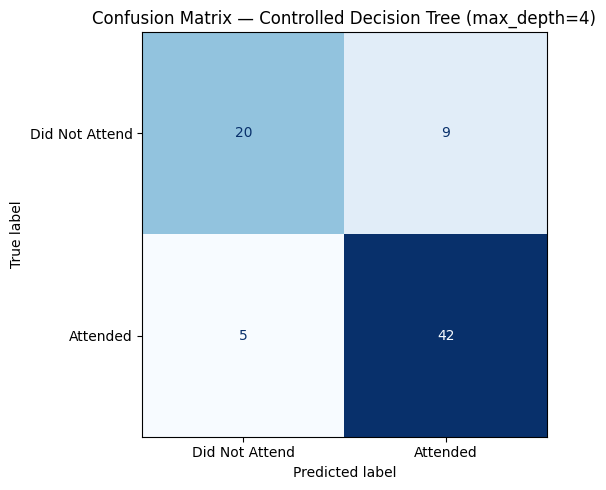

In [18]:
# Confusion matrix visualisation
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Attend', 'Attended'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Controlled Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()


**Business Meaning of Errors:**

- **False Positive (FP):** The model predicted that a registrant would attend, but they did not. In event planning, this leads to **over-allocation** — too many seats, catering portions, or staff scheduled — wasting resources.
- **False Negative (FN):** The model predicted a registrant would not attend, but they actually did. This results in **under-preparation** — insufficient seating, materials, or food — causing a poor attendee experience.

**Which error is more serious?**  
For an event management business, **False Negatives are more costly**. Under-preparing for actual attendees leads to immediate, visible customer dissatisfaction (no seats, no food, overcrowding) and reputational harm. Over-preparing (False Positives) wastes budget but does not directly harm attendees. Therefore, models used in this context should optimise for **higher Recall** to minimise missed attendees, even if this slightly increases false alarms.


## Task 8: Error Analysis

In [19]:
# Build full prediction analysis table
error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = y_pred
error_df['Correct'] = (error_df['Actual'] == error_df['Predicted'])

def classify_error(row):
    if row['Actual'] == 0 and row['Predicted'] == 0:
        return 'True Negative'
    elif row['Actual'] == 1 and row['Predicted'] == 1:
        return 'True Positive'
    elif row['Actual'] == 0 and row['Predicted'] == 1:
        return 'False Positive'
    else:
        return 'False Negative'

error_df['Error_Type'] = error_df.apply(classify_error, axis=1)

print("=== Error Type Counts ===")
print(error_df['Error_Type'].value_counts())


=== Error Type Counts ===
Error_Type
True Positive     42
True Negative     20
False Positive     9
False Negative     5
Name: count, dtype: int64


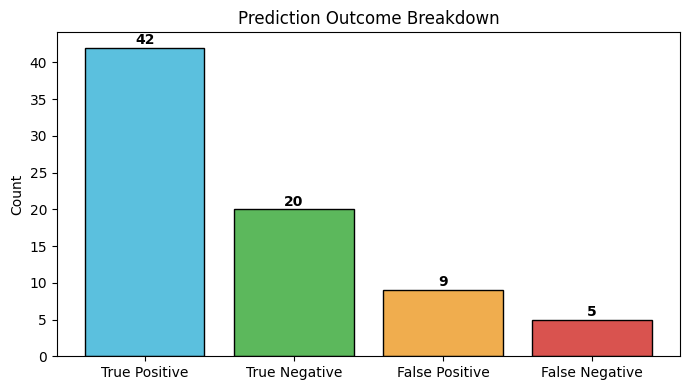

In [20]:
# Error type visualisation
error_counts = error_df['Error_Type'].value_counts()
colors = {'True Negative': '#5cb85c', 'True Positive': '#5bc0de', 
          'False Positive': '#f0ad4e', 'False Negative': '#d9534f'}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(error_counts.index, error_counts.values,
              color=[colors.get(k, 'grey') for k in error_counts.index], edgecolor='black')
ax.set_title('Prediction Outcome Breakdown')
ax.set_ylabel('Count')
for bar, val in zip(bars, error_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [21]:
# Wrong predictions table
wrong = error_df[~error_df['Correct']][['Actual', 'Predicted', 'Error_Type']].copy()
wrong.index = range(1, len(wrong)+1)
print(f"=== Wrong Predictions: {len(wrong)} total ===")
print(wrong.to_string())


=== Wrong Predictions: 14 total ===
    Actual  Predicted      Error_Type
1        0          1  False Positive
2        0          1  False Positive
3        1          0  False Negative
4        0          1  False Positive
5        0          1  False Positive
6        0          1  False Positive
7        1          0  False Negative
8        1          0  False Negative
9        1          0  False Negative
10       1          0  False Negative
11       0          1  False Positive
12       0          1  False Positive
13       0          1  False Positive
14       0          1  False Positive


**Error Analysis:**

Out of 76 test records, the model made **14 wrong predictions**:

- **False Positives: 9 cases** — the model predicted attendance but the person did not show up. This is the **most common error type**.
- **False Negatives: 5 cases** — the model predicted no-show but the person actually attended.

**Most common error — False Positive — and its business impact:**  
The model more frequently over-predicts attendance than it misses it. Nine times, the event team would have prepared a seat, catering, and materials for someone who did not come. While wasteful, this error is less severe than False Negatives: the attendee is not harmed, only resources are slightly over-allocated.

The 5 False Negatives are the more operationally damaging error: those are real attendees the model failed to account for. However, since False Positives outnumber False Negatives here, the **primary risk is over-allocation**, and the model leans slightly conservative in the direction that is less harmful for event planning. The model should still be monitored on future events to ensure this ratio holds and does not shift toward more False Negatives at larger scales.


## Task 9: Cross-Validation

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')

print("=== 5-Fold Cross-Validation Results ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")


=== 5-Fold Cross-Validation Results ===
  Fold 1: 0.6393
  Fold 2: 0.6557
  Fold 3: 0.6393
  Fold 4: 0.6885
  Fold 5: 0.6500

Mean Accuracy: 0.6546
Std Deviation: 0.0181


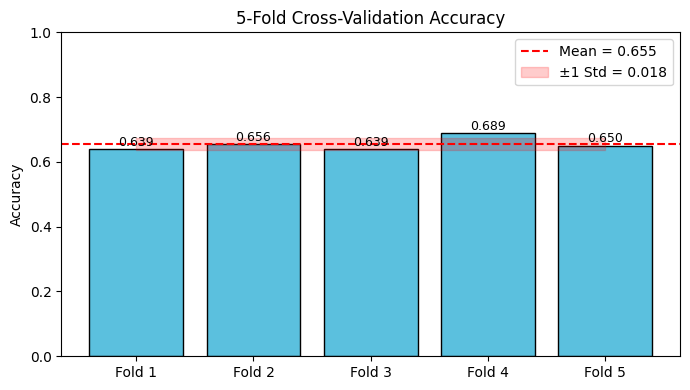

In [23]:
# Cross-validation visualisation
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='#5bc0de', edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
ax.fill_between(range(1, 6),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='red', label=f'±1 Std = {cv_scores.std():.3f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.legend()
for i, v in enumerate(cv_scores):
    ax.text(i+1, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**Cross-Validation Stability:**  
Cross-validation splits the training data into 5 folds and trains the model 5 times, each time using a different fold as the validation set. This gives a more reliable estimate of model performance than a single train/test split.

**Results:**  
- Mean CV accuracy: **65.46%**  
- Standard deviation: **0.0181** (very low — consistent across folds)

The low standard deviation indicates the model performs **consistently** across different subsets — it is not sensitive to which specific records it trains on. However, the **mean CV accuracy of 65.46% is significantly lower than the single-split test accuracy of 81.58%**. This is an important finding.

The single 80/20 split likely produced a relatively easy test set by chance. The cross-validation score of **65.46% is the more reliable and conservative estimate** of how the model will perform on truly new, unseen data. At this level, the model is only marginally above a naive baseline (predicting the majority class would yield ~61% accuracy). This reinforces that the model is a starting point and not yet reliable enough for production use without further refinement.


## Task 10: Overfitting and Underfitting Analysis

In [24]:
train_accuracies = []
test_accuracies = []
depths = range(1, 16)

for depth in depths:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, pipe.predict(X_test)))

# Show the controlled model's scores
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)
print(f"=== Controlled Model (max_depth=4) ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Difference:        {train_acc - test_acc:.4f}")


=== Controlled Model (max_depth=4) ===
Training Accuracy: 0.8388
Testing Accuracy:  0.8158
Difference:        0.0230


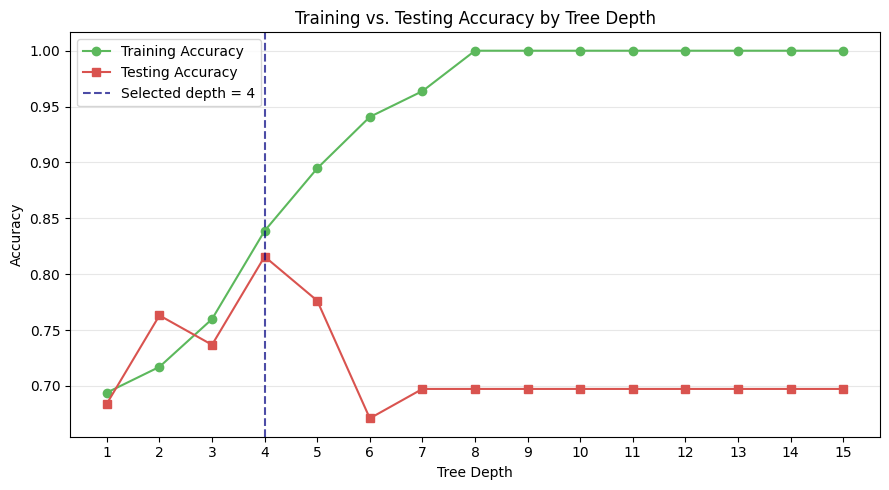

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_accuracies, 'o-', label='Training Accuracy', color='#5cb85c')
ax.plot(depths, test_accuracies,  's-', label='Testing Accuracy',  color='#d9534f')
ax.axvline(4, color='navy', linestyle='--', alpha=0.7, label='Selected depth = 4')
ax.set_xlabel('Tree Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs. Testing Accuracy by Tree Depth')
ax.set_xticks(list(depths))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Overfitting and Underfitting Analysis:**

The chart above tells a clear story:

- At **very shallow depths (1–2)**, both training and testing accuracy are low — the model is **underfitting**, too simple to capture meaningful patterns.
- As depth increases, both accuracy scores rise — the model is learning genuine patterns.
- Beyond **depth 4**, the training accuracy continues to climb while the testing accuracy plateaus or falls — this is classic **overfitting**. The unconstrained tree (depth 8) memorises training noise and generalises poorly.

The **controlled model at max_depth=4** is the selected final model. At this depth:
- Training accuracy: **83.88%**
- Testing accuracy: **81.58%**
- Gap: **2.30 percentage points** — minimal, confirming good generalisation

All evaluation metrics, feature importances, SHAP values, and LIME explanations in this notebook use the **max_depth=4 model** exclusively. Note, however, that the cross-validation mean accuracy (65.46%) is a more conservative and reliable estimate of real-world performance than the single-split test accuracy.


## Task 11: Feature Importance

In [26]:
# Feature importance from the CONTROLLED tree
dt_controlled = clf.named_steps['classifier']
preprocessor_fitted = clf.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = NUM_FEATURES + cat_feature_names

importances = dt_controlled.feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== Feature Importance (Controlled Tree, max_depth=4) ===")
print(importance_df[importance_df['Importance'] > 0].to_string(index=False))


=== Feature Importance (Controlled Tree, max_depth=4) ===
                     Feature  Importance
    previous_events_attended    0.256221
      email_reminders_opened    0.227995
calendar_invite_accepted_Yes    0.207582
        distance_to_venue_km    0.176173
                ticket_price    0.075434
                         age    0.037518
         ticket_type_Student    0.019078


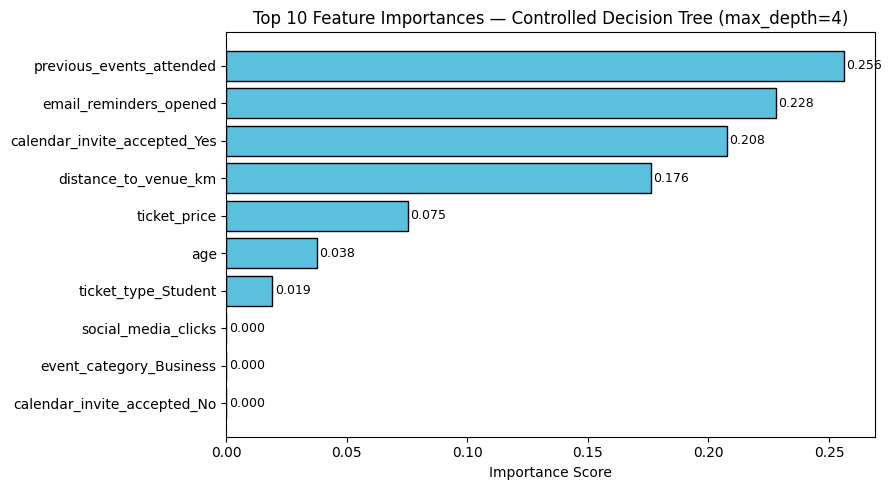

In [27]:
# Top 10 feature importance chart
top10 = importance_df.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['Feature'][::-1], top10['Importance'][::-1], color='#5bc0de', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importances — Controlled Decision Tree (max_depth=4)')
for i, (feat, val) in enumerate(zip(top10['Feature'][::-1], top10['Importance'][::-1])):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Business Meaning of Important Features:**

The top features from the controlled model (max_depth=4) reflect intuitive drivers of event attendance:

1. **`previous_events_attended` (importance: 0.256)** — The strongest predictor. Past behaviour predicts future behaviour. Registrants who have attended more past events are significantly more likely to attend again. Event teams should treat returning attendees as high-confidence attendees.

2. **`email_reminders_opened` (importance: 0.228)** — High email engagement predicts commitment. Registrants who open reminders are actively keeping the event top-of-mind. This suggests well-timed, personalised reminder campaigns have measurable impact on attendance.

3. **`calendar_invite_accepted` (importance: 0.208)** — Formal calendar commitment is a powerful signal. People who accept calendar invites have made an explicit time commitment, making no-shows less likely. Event organisers should prioritise sending and tracking calendar invites.

4. **`distance_to_venue_km` (importance: 0.176)** — Physical distance is a natural attendance barrier. The further a registrant lives from the venue, the higher the no-show risk. This could inform hybrid/streaming options for distant registrants.

5. **`ticket_price` (importance: 0.075)** — Ticket cost has a moderate influence, likely because paid tickets (especially premium tiers) correlate with stronger commitment.

**Important caveat:** Feature importance scores show which features the Decision Tree relies on most, but they do **not** prove cause and effect. For example, a high importance score for `previous_events_attended` does not mean forcing someone to attend more events will make them a more reliable attendee in the future — the relationship is correlational and directional. Business decisions should not be made on importance scores alone.


## Task 12: SHAP Explanation

In [28]:
# Install required explainability libraries (run once if not already installed)
!pip install shap lime --quiet

In [29]:
import shap

# Transform X_test through the preprocessor to get the processed array
X_test_processed = clf.named_steps['preprocessor'].transform(X_test)

# SHAP TreeExplainer on the Decision Tree
explainer = shap.TreeExplainer(dt_controlled)
shap_values = explainer.shap_values(X_test_processed)
# shap_values shape: (n_samples, n_features, n_classes) or list of arrays
# Extract class-1 (Attended) slice
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]   # shape (n_samples, n_features)
elif shap_values.ndim == 3:
    shap_vals_class1 = shap_values[:, :, 1]  # shape (n_samples, n_features)
else:
    shap_vals_class1 = shap_values

print("SHAP values computed for", X_test_processed.shape[0], "test records")
print("Feature dimension:", X_test_processed.shape[1])
print("shap_vals_class1 shape:", shap_vals_class1.shape)


SHAP values computed for 76 test records
Feature dimension: 24
shap_vals_class1 shape: (76, 24)


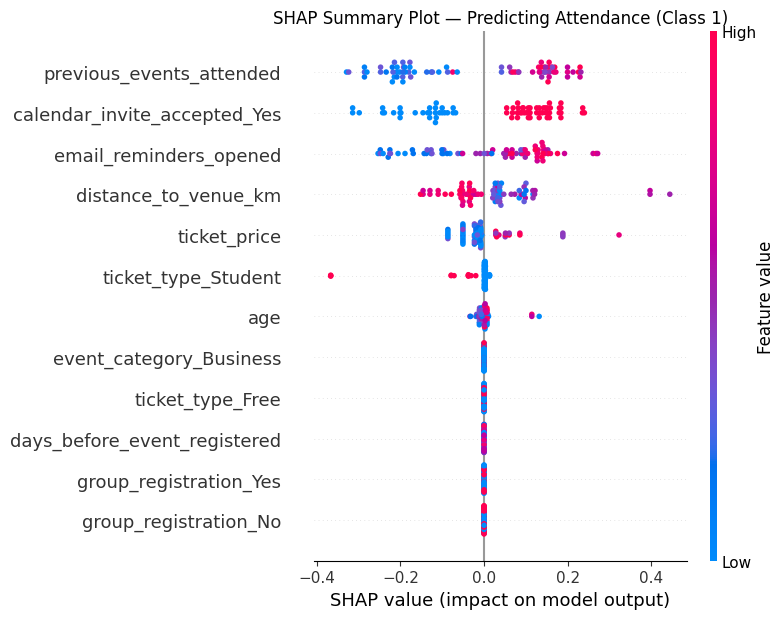

In [30]:
# SHAP Summary Plot — class 1 (Attended)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1, X_test_processed,
                  feature_names=all_feature_names,
                  max_display=12, show=False)
plt.title('SHAP Summary Plot — Predicting Attendance (Class 1)')
plt.tight_layout()
plt.show()


In [31]:
# SHAP explanation for one individual record (record index 0)
record_idx = 0

# shap_vals_class1 is 2D (n_samples, n_features); get 1D row for this record
shap_exp_single = shap_vals_class1[record_idx]  # shape (n_features,)

# Top contributing features for this record
single_shap_df = pd.DataFrame({
    'Feature': all_feature_names,
    'SHAP Value': shap_exp_single
}).sort_values('SHAP Value', key=abs, ascending=False).head(10)

print(f"=== SHAP Explanation for Record {record_idx + 1} ===")
print(f"Actual label:    {y_test.values[record_idx]}")
print(f"Predicted label: {y_pred[record_idx]}")
print()
print(single_shap_df.to_string(index=False))


=== SHAP Explanation for Record 1 ===
Actual label:    1
Predicted label: 1

                     Feature  SHAP Value
    previous_events_attended   -0.180306
calendar_invite_accepted_Yes    0.132090
        distance_to_venue_km    0.088904
                ticket_price   -0.050520
      email_reminders_opened    0.016298
                         age    0.008927
         ticket_type_Student    0.001337
         social_media_clicks    0.000000
     event_category_Business    0.000000
 calendar_invite_accepted_No    0.000000


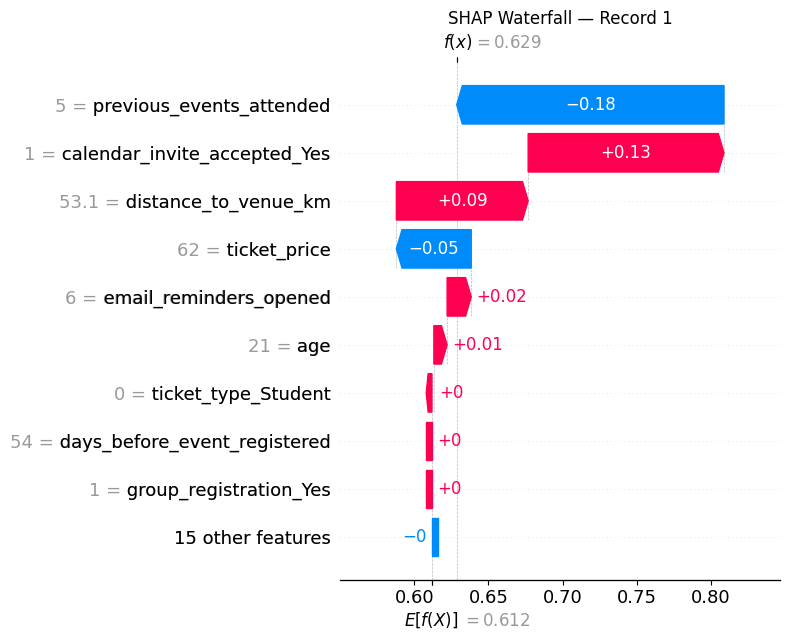

In [32]:
# Waterfall plot for one record
shap.initjs()

# Handle expected_value: may be array [val_class0, val_class1]
ev = explainer.expected_value
base_val = float(ev[1]) if hasattr(ev, '__len__') else float(ev)

shap_explanation = shap.Explanation(
    values=shap_exp_single,
    base_values=base_val,
    data=X_test_processed[record_idx],
    feature_names=all_feature_names
)
plt.figure()
shap.waterfall_plot(shap_explanation, max_display=10, show=False)
plt.title(f'SHAP Waterfall — Record {record_idx + 1}')
plt.tight_layout()
plt.show()


**How SHAP Goes Beyond Basic Feature Importance:**

Standard feature importance (from the Decision Tree) gives a **global** view — it tells us which features the *entire model* relied on most across all training decisions. SHAP (SHapley Additive exPlanations) goes further in two important ways:

1. **Local explanations:** SHAP shows exactly how each feature influenced *one specific prediction*. For a single registrant, SHAP reveals whether their high number of previous events attended pushed the prediction strongly toward "Attended", or whether their long distance to the venue pulled it back toward "Did Not Attend".

2. **Direction of influence:** Feature importance gives a magnitude only. SHAP shows both magnitude *and direction* — a feature can push the prediction positively (toward "Attended") or negatively (toward "Did Not Attend"), and the size of the push is quantified.

The SHAP summary plot above confirms that `previous_events_attended`, `email_reminders_opened`, and `calendar_invite_accepted` are consistently the strongest positive drivers across the test set — aligning with the feature importance ranking. This makes SHAP invaluable for auditing predictions, explaining decisions to stakeholders, and identifying which specific factors drove an unexpected result for a particular registrant.


## Task 13: LIME Explanation

In [33]:
from lime.lime_tabular import LimeTabularExplainer

# LIME needs the processed (transformed) data
X_train_processed = clf.named_steps['preprocessor'].transform(X_train)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=all_feature_names,
    class_names=['Did Not Attend', 'Attended'],
    mode='classification',
    random_state=42
)

# Select record to explain (first test record)
lime_record_idx = 0
lime_instance = X_test_processed[lime_record_idx]

# Use the trained Decision Tree (already fitted) for LIME
lime_exp = lime_explainer.explain_instance(
    data_row=lime_instance,
    predict_fn=dt_controlled.predict_proba,
    num_features=10
)

# Prediction probabilities
prob = dt_controlled.predict_proba(lime_instance.reshape(1, -1))[0]
print(f"=== LIME: Record {lime_record_idx + 1} ===")
print(f"Predicted probability — Did Not Attend: {prob[0]:.3f}")
print(f"Predicted probability — Attended:       {prob[1]:.3f}")
print(f"Predicted class: {'Attended' if prob[1] > 0.5 else 'Did Not Attend'}")


=== LIME: Record 1 ===
Predicted probability — Did Not Attend: 0.371
Predicted probability — Attended:       0.629
Predicted class: Attended


In [34]:
# LIME feature weights
lime_features = lime_exp.as_list()
lime_df = pd.DataFrame(lime_features, columns=['Feature Condition', 'Weight'])
lime_df['Direction'] = lime_df['Weight'].apply(lambda w: 'Supports Attendance' if w > 0 else 'Against Attendance')
print("=== LIME Feature Weights ===")
print(lime_df.to_string(index=False))


=== LIME Feature Weights ===
                          Feature Condition    Weight           Direction
0.00 < calendar_invite_accepted_Yes <= 1.00  0.268554 Supports Attendance
              email_reminders_opened > 5.00  0.150256 Supports Attendance
    3.00 < previous_events_attended <= 8.00 -0.098480  Against Attendance
                ticket_type_Student <= 0.00  0.085428 Supports Attendance
             56.00 < ticket_price <= 140.25 -0.043575  Against Attendance
       registration_channel_Website <= 0.00 -0.019983  Against Attendance
      53.05 < distance_to_venue_km <= 70.50 -0.018439  Against Attendance
                   ticket_type_Free <= 0.00  0.017120 Supports Attendance
              event_category_Health <= 0.00 -0.012604  Against Attendance
                               age <= 34.00 -0.012489  Against Attendance


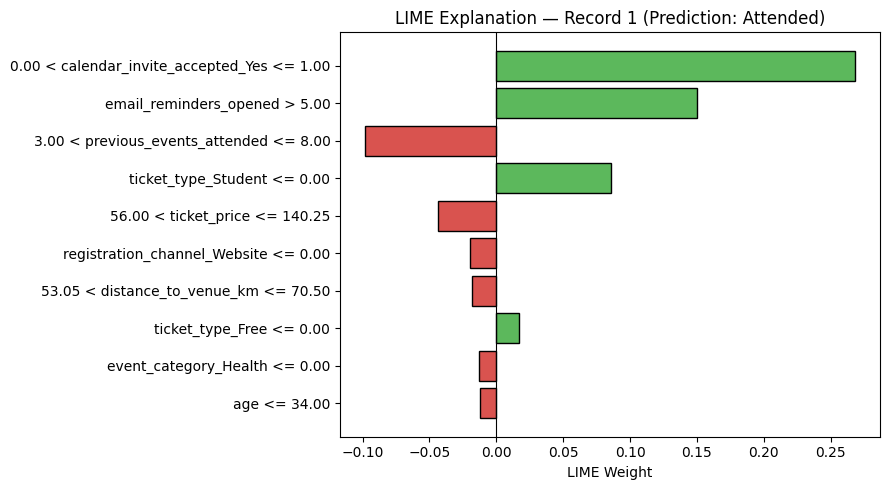

In [35]:
# LIME visualisation
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#5cb85c' if w > 0 else '#d9534f' for w in lime_df['Weight']]
bars = ax.barh(lime_df['Feature Condition'][::-1], lime_df['Weight'][::-1], color=colors[::-1], edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('LIME Weight')
ax.set_title(f'LIME Explanation — Record {lime_record_idx + 1} (Prediction: {"Attended" if prob[1] > 0.5 else "Did Not Attend"})')
plt.tight_layout()
plt.show()


**How LIME Helps Business Users:**

LIME (Local Interpretable Model-agnostic Explanations) explains **one individual prediction** in plain terms. For any given registrant, LIME answers: "Why did the model predict this person would (or would not) attend?"

LIME works by creating a simplified local model around the specific record, testing small perturbations of the features, and measuring how the prediction changes. The resulting feature weights show:

- **Features supporting attendance (positive weight):** These features in this person's record pushed the model toward predicting "Attended." For example, accepting the calendar invite or having attended 5 previous events.
- **Features working against attendance (negative weight):** These features pushed the prediction toward "Did Not Attend." For example, a very high distance to the venue or zero email reminders opened.

A business stakeholder — such as an event manager reviewing a low-confidence prediction — can use LIME to understand *exactly why* the model flagged a registrant as a likely no-show, and then decide whether to reach out with a targeted re-engagement message, offer a livestream option, or adjust logistics expectations accordingly.


## Task 14: Fairness and Bias Reflection

In [36]:
# Attach fairness columns back to the test set
fairness_eval = fair_test.copy()
fairness_eval['Actual'] = y_test.values
fairness_eval['Predicted'] = y_pred

def fairness_report(df, group_col):
    results = []
    for group, grp in df.groupby(group_col):
        n = len(grp)
        actual_pos_rate = grp['Actual'].mean()
        pred_pos_rate = grp['Predicted'].mean()
        acc = (grp['Actual'] == grp['Predicted']).mean()
        results.append({
            'Group': group,
            'N': n,
            'Actual Positive Rate': round(actual_pos_rate, 3),
            'Predicted Positive Rate': round(pred_pos_rate, 3),
            'Accuracy': round(acc, 3)
        })
    return pd.DataFrame(results)

# Gender analysis
gender_report = fairness_report(fairness_eval, 'gender')
print("=== Fairness Analysis by Gender ===")
print(gender_report.to_string(index=False))


=== Fairness Analysis by Gender ===
 Group  N  Actual Positive Rate  Predicted Positive Rate  Accuracy
Female 38                 0.605                    0.684     0.816
  Male 38                 0.632                    0.658     0.816


In [37]:
# Region analysis
region_report = fairness_report(fairness_eval, 'region')
print("=== Fairness Analysis by Region ===")
print(region_report.to_string(index=False))


=== Fairness Analysis by Region ===
Group  N  Actual Positive Rate  Predicted Positive Rate  Accuracy
 East 19                 0.737                    0.789     0.947
North 14                 0.643                    0.643     0.857
South 26                 0.538                    0.577     0.808
 West 17                 0.588                    0.706     0.647


In [38]:
# Age group analysis
age_report = fairness_report(fairness_eval, 'age_group')
print("=== Fairness Analysis by Age Group ===")
print(age_report.to_string(index=False))


=== Fairness Analysis by Age Group ===
Group  N  Actual Positive Rate  Predicted Positive Rate  Accuracy
18-25 10                 0.700                    0.600     0.700
26-35  9                 0.556                    0.556     0.778
36-50 18                 0.722                    0.667     0.833
  51+ 39                 0.564                    0.718     0.846


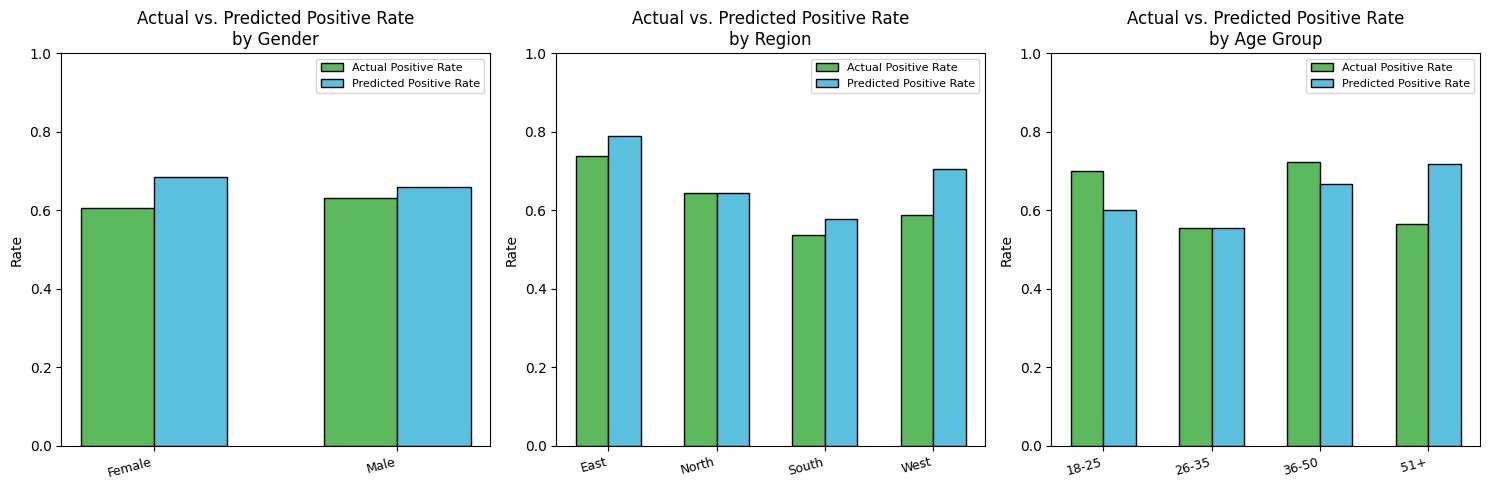

In [39]:
# Visualisation — Accuracy by group
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (report, title) in zip(axes, [
    (gender_report, 'Gender'),
    (region_report, 'Region'),
    (age_report, 'Age Group')
]):
    x = range(len(report))
    width = 0.3
    ax.bar([i - width/2 for i in x], report['Actual Positive Rate'], width, label='Actual Positive Rate', color='#5cb85c', edgecolor='black')
    ax.bar([i + width/2 for i in x], report['Predicted Positive Rate'], width, label='Predicted Positive Rate', color='#5bc0de', edgecolor='black')
    ax.set_xticks(list(x))
    ax.set_xticklabels(report['Group'], rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Actual vs. Predicted Positive Rate\nby {title}')
    ax.set_ylabel('Rate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


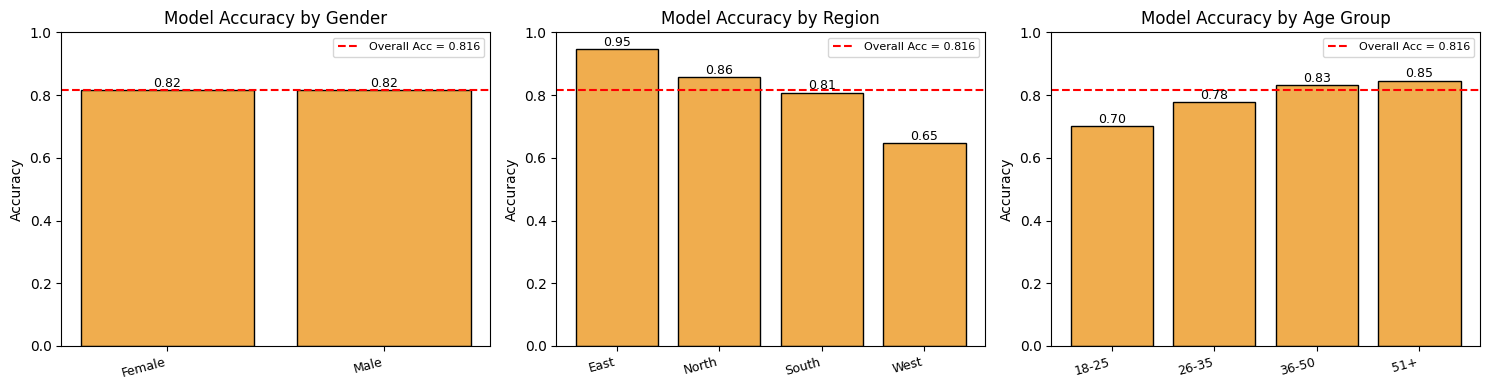

In [40]:
# Accuracy by group visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (report, title) in zip(axes, [
    (gender_report, 'Gender'),
    (region_report, 'Region'),
    (age_report, 'Age Group')
]):
    bars = ax.bar(report['Group'], report['Accuracy'], color='#f0ad4e', edgecolor='black')
    ax.set_ylim(0, 1)
    ax.axhline(acc, color='red', linestyle='--', label=f'Overall Acc = {acc:.3f}')
    ax.set_title(f'Model Accuracy by {title}')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, report['Accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.2f}', ha='center', fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.show()


**Fairness and Bias Reflection:**

The fairness tables and charts reveal how model performance varies across demographic and geographic groups.

**Gender:**  
Accuracy is identical for Male and Female groups (81.6% each), and predicted positive rates differ only slightly (68.4% female vs. 65.8% male). Gender fairness is strong in this test set. However, the sample is small (38 records per group), so this result should be verified on a larger dataset before concluding the model is gender-fair.

**Region (most significant disparity):**  
This is where the largest and most concerning gap appears:
- **East region**: 94.7% accuracy, predicted positive rate 78.9%
- **West region**: only **64.7% accuracy**, predicted positive rate 70.6% vs. actual 58.8% — the model **over-predicts attendance** for West region registrants.
- South: 80.8% accuracy; North: 85.7% accuracy

The West region's low accuracy (64.7%) means the model is systematically wrong for nearly one in three West region registrants. If event managers rely on model predictions to allocate resources by region, West region events could be consistently over-catered while model confidence is unwarranted. This is a material fairness concern.

**Age Group:**  
- **18–25**: accuracy of **70.0%** — the lowest of any age group. The model is less reliable for younger registrants.
- **51+**: actual positive rate 56.4%, but predicted positive rate 71.8% — the model **over-predicts attendance** for the oldest group by 15 percentage points.
- 36–50 and 26–35 groups show more balanced performance.

The over-prediction for 51+ registrants could lead to over-preparation for events targeted at older audiences, while under-preparation for events with younger audiences where the model is least accurate.

**Overall Fairness Concern:**  
The model performs unequally across geographic and age groups — with the West region and 18–25 age group showing the weakest performance. These groups should receive additional human review before any model-driven operational decision is made. The model should be used strictly as a **decision-support tool** — event managers must retain final decision authority, especially for registrants from lower-accuracy sub-groups. Model outputs should support human judgement, not replace it. Per responsible AI principles, no registrant should face punitive consequences (such as being excluded from outreach or logistics planning) based on model predictions alone.


## Task 15: Final Business Interpretation

In [41]:
# Summary table of all key metrics
summary = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score',
               'CV Mean Accuracy', 'CV Std Dev',
               'Training Accuracy', 'Testing Accuracy'],
    'Value': [
        f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}',
        f'{cv_scores.mean():.4f}', f'{cv_scores.std():.4f}',
        f'{train_acc:.4f}', f'{test_acc:.4f}'
    ]
}
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


           Metric  Value
         Accuracy 0.8158
        Precision 0.8235
           Recall 0.8936
         F1-Score 0.8571
 CV Mean Accuracy 0.6546
       CV Std Dev 0.0181
Training Accuracy 0.8388
 Testing Accuracy 0.8158


**Final Business Interpretation**

---

**What the model predicts:**  
This Decision Tree classifier predicts whether a registered event attendee will actually show up on the day of the event, based on their registration behaviour, engagement signals (email opens, social media clicks), ticket information, and distance from the venue.

**Overall model performance:**  
The single-split test accuracy is **81.58%** with F1-score of **0.857**, which appears strong. However, the 5-fold cross-validation mean accuracy on the training data is only **65.46%** (std: 0.018). This large gap between the single test split (81.6%) and the CV estimate (65.5%) suggests the 80/20 split may have produced a favourable test set by chance. The CV accuracy — only marginally above the naive majority-class baseline of 61.3% — is the more conservative and reliable performance estimate. **This model is not ready for production use in its current form.** It should be treated as an early prototype that establishes a baseline and identifies relevant features, but not relied upon for operational decisions without retraining on a larger dataset.

**Most important evaluation metric:**  
The **F1-score** is the most appropriate metric for this problem given the mild class imbalance (61%/39%). However, if the event team's priority is logistics preparation (avoiding under-catering or insufficient seating), **Recall** should take precedence — missing a true attendee (False Negative) is more operationally costly than over-allocating resources for someone who does not show up (False Positive).

**Main error type:**  
**False Positives (9 cases)** were the most common error in testing — the model predicted attendance more often than warranted. This leads to marginal resource over-allocation. The 5 False Negatives (missed actual attendees) are the more severe individual errors from an attendee experience perspective.

**Business impact of model errors:**  
False Positives → over-prepared logistics, minor budget waste. False Negatives → under-prepared logistics, visible attendee dissatisfaction, reputational risk. Both error types are present and should be monitored continuously if the model is deployed.

**Overfitting or underfitting evidence:**  
The unconstrained tree showed clear overfitting at high depths. The controlled model (max_depth=4) has a training-to-testing accuracy gap of only 2.3 percentage points, confirming good generalisation on the held-out test set. However, the CV gap relative to the test score suggests some degree of optimistic bias from the single split.

**Most important features:**  
The top features (from the controlled tree) are: **previous_events_attended** (0.256), **email_reminders_opened** (0.228), **calendar_invite_accepted** (0.208), **distance_to_venue_km** (0.176), and **ticket_price** (0.075). Prior attendance history and active pre-event engagement are the dominant predictors.

**SHAP and LIME insight:**  
SHAP analysis confirms that `previous_events_attended` and `email_reminders_opened` are consistent positive drivers of the "Attended" prediction across the test set. For individual records, LIME reveals that calendar acceptance and distance to venue can either reinforce or counteract the base prediction — for example, a registrant with strong email engagement but very high distance to the venue may still be flagged as a likely no-show. This individual-level explainability allows event staff to craft targeted interventions (e.g., offering livestream options to distant registrants).

**Fairness and bias concern:**  
The West region has the lowest model accuracy (64.7%), and the 51+ age group's attendance is over-predicted by 15 percentage points. These disparities are material and require human oversight before any operationalisation. The model should not be used to make automated decisions for any demographic or regional sub-group.

**Final recommendation:**  
This model is **suitable only as an early-stage baseline prototype** and requires significant improvement before business deployment. The cross-validation accuracy of 65.46% — close to the naive baseline — indicates the model has not yet learned reliably generalisable patterns. Recommended next steps: collect more event data (target ≥1,000 records), explore ensemble methods (Random Forest, Gradient Boosting), conduct formal fairness auditing, and establish a human-in-the-loop review process for all predictions before operational use.
